In [1]:
%load_ext autoreload
%autoreload 2

from dqn_agent import Agent

torch.Size([4])
tensor([ 0.1737,  0.6811,  0.0380, -0.5475], grad_fn=<ViewBackward0>)


In [2]:
import gymnasium as gym
from collections import deque
import numpy as np
import torch
import matplotlib.pyplot as plt
env = gym.make("LunarLander-v3")
# (x,y, x_speed, y_speed, angle, angle_speed, касание левой опорой, касание правой опорой
state_size = env.observation_space.shape[0]  # Извлекаем целое число из кортежа (8,)
action_size = env.action_space.n

agent = Agent(state_size, action_size, seed=1)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
agent

Эпизод 100	Средняя награда: -91.13 эпизодов): -91.13
Эпизод 200	Средняя награда: -24.35 эпизодов): -24.35

🎥 Запуск демонстрации для эпизода 200...
✅ Демонстрация завершена. Продолжаем обучение...

Эпизод 300	Средняя награда: 67.590 эпизодов): 67.595
Эпизод 400	Средняя награда: 205.52 эпизодов): 205.52

🎥 Запуск демонстрации для эпизода 400...
✅ Демонстрация завершена. Продолжаем обучение...

Эпизод 500	Средняя награда: 225.34 эпизодов): 225.34
Эпизод 600	Средняя награда: 236.43 эпизодов): 236.43

🎥 Запуск демонстрации для эпизода 600...
✅ Демонстрация завершена. Продолжаем обучение...

Эпизод 700	Средняя награда: 256.54 эпизодов): 256.54
Эпизод 800	Средняя награда: 261.45 эпизодов): 261.45

🎥 Запуск демонстрации для эпизода 800...
✅ Демонстрация завершена. Продолжаем обучение...

Эпизод 900	Средняя награда: 264.11 эпизодов): 264.11
Эпизод 1000	Средняя награда: 265.05 эпизодов): 265.05

🎥 Запуск демонстрации для эпизода 1000...
✅ Демонстрация завершена. Продолжаем обучение...



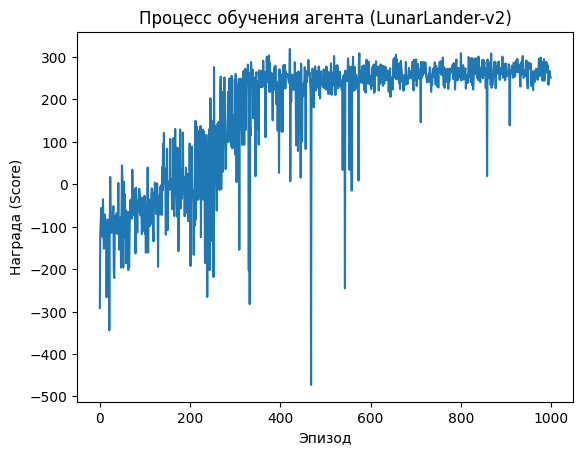

In [ ]:
def train(episodes=1000, max_t=1000, eps_start=1.0, eps_end=0.01, eps_decay=0.995):
    scores=[]
    scores_window = deque(maxlen=100)
    eps=eps_start

    for episode in range(1, episodes+1):
        state, info = env.reset()
        score = 0

        for t in range(max_t):
            action = agent.act(state, eps) # predict модели
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated # завершен или истек по времени
            agent.step(state, action, reward, next_state, done)

            state=next_state
            score+=reward
            if done: break
        
        scores_window.append(score)
        scores.append(score)
        eps = max(eps_end, eps_decay * eps)

        print(f'\rЭпизод {episode}\tСредняя награда (за 100 эпизодов): {np.mean(scores_window):.2f}', end="")
        
        if episode % 100 == 0:
            print(f'\rЭпизод {episode}\tСредняя награда: {np.mean(scores_window):.2f}')
        
        if episode==episodes:
            torch.save(agent.qnetwork_local.state_dict(), 'final_network.pth')
        # --- НОВЫЙ БЛОК: ДЕМОНСТРАЦИЯ КАЖДЫЕ 200 ЭПИЗОДОВ ---
        if episode % 200 == 0:
            print(f"\n🎥 Запуск демонстрации для эпизода {episode}...")
            # Создаем среду специально для отрисовки
            env_render = gym.make('LunarLander-v3', render_mode='human')
            state_render, _ = env_render.reset()
            done_render = False
            
            while not done_render:
                action_render = agent.act(state_render, eps=0.0) 
                
                next_state_render, _, terminated_render, truncated_render, _ = env_render.step(action_render)
                state_render = next_state_render
                done_render = terminated_render or truncated_render
                
            env_render.close() 
            print("✅ Демонстрация завершена. Продолжаем обучение...\n")
            
    return scores
        

scores = train()
# Строим график процесса обучения
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Награда (Score)')
plt.xlabel('Эпизод')
plt.title('Процесс обучения агента (LunarLander-v2)')
plt.show()

env.close()